### Introduction to data analysis

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mailbox

In [2]:
iris_df = sns.load_dataset("iris")

In [3]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 8C26-25D6

 Directory of C:\Users\USER\Documents\DATA SCIENCE

09/10/2025  01:18 PM    <DIR>          .
08/10/2025  12:15 AM    <DIR>          ..
08/24/2025  01:40 PM            23,792 11-08-25 Functions.ipynb
08/27/2025  01:36 PM            24,596 16-07-25 SET.ipynb
08/05/2025  08:42 AM            23,806 21-07-25 Conditional Statements in Python.ipynb
08/05/2025  08:42 AM            24,814 28-07-25 for loops.ipynb
08/07/2025  06:15 AM        93,658,994 All mail Including Spam and Trash.mbox
08/25/2025  02:43 PM    <DIR>          Data-Science-Community
09/08/2025  01:59 PM    <DIR>          Data-Science-testing-collaboration
08/05/2025  08:42 AM            18,837 Dictionaries 14-07-25.ipynb
09/09/2025  02:27 PM           192,503 gmail_data.csv
09/10/2025  01:18 PM         1,051,363 INTODUCTION TO DATA ANALYSIS.ipynb
08/27/2025  05:06 PM            17,954 Introduction to Data Analysis - August 27.ipynb
08/27/2025  02:41 PM       

## Put the mbox into a variable

In [5]:
mboxfile = "All mail Including Spam and Trash.mbox"

## Extract the file from the mbox file¶

In [6]:
mbox = mailbox.mbox(mboxfile)
mbox

#### *Extract the keys inside the inbox file*

In [7]:
for key in mbox[0].keys():
    print(key)

X-GM-THRID
X-Gmail-Labels
Delivered-To
Received
X-Google-Smtp-Source
X-Received
ARC-Seal
ARC-Message-Signature
ARC-Authentication-Results
Return-Path
Received
Received-SPF
Authentication-Results
DKIM-Signature
DKIM-Signature
Received
Received
Content-Transfer-Encoding
Content-Type
Date
From
Mime-Version
Message-ID
Subject
Reply-To
Feedback-ID
List-Unsubscribe
List-Unsubscribe-Post
x-campaignid
X-SG-EID
X-SG-ID
To
X-Entity-ID


## Data Transformation

- The data isn't in a format that is usable

- The file format isn't usable

In [8]:
import csv

In [9]:
# Create a csv file with only the required attributes:
with open("mailbox.csv", "w") as outputfile:
    writer = csv.writer(outputfile)
    writer.writerow(["subject", "from", "date", "to", "label", "thread"])
    for message in mbox:
        writer.writerow([
            message["subject"], message["from"], message["date"],
            message["to"], message["X-Gmail-Labels"], message["X-GM-THRID"]
        ])

In [10]:
gmail_data = pd.read_csv("mailbox.csv")
gmail_data.head()

,subject,from,date,to,label,thread
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,Audiomack =?UTF-8?b?8J+Utg==?= <no-reply@marke...,"Wed, 18 Jun 2025 21:20:50 +0000 (UTC)",jemimahlabaran6@gmail.com,"Inbox,Category promotions,Unread",1835303697494005545
1,Drowning is a Leading Cause of Death for Children,"""Statista | Daily Data"" <dailydata.en@news.sta...","Fri, 25 Jul 2025 16:04:01 +0000",jemimahlabaran6@gmail.com,"Inbox,Category updates,Unread",1838635497547678405
2,Mobile Money Accounts Surpass Banks in Low-Inc...,"""Statista | Daily Data"" <dailydata.en@news.sta...","Fri, 18 Jul 2025 14:38:23 +0000",jemimahlabaran6@gmail.com,"Inbox,Category updates,Unread",1837996059195159190
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,Google tips and updates <googlecommunityteam-n...,"Tue, 08 Jul 2025 05:59:07 -0700",jemimahlabaran6@gmail.com,"Inbox,Category updates,Unread",1837083706639031221
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,"""Grammarly Insights"" <hello@mail.grammarly.com>","Mon, 02 Jun 2025 18:03:25 +0000",jemimahlabaran6@gmail.com,"Inbox,Category updates,Unread",1833841361233796687


In [11]:
gmail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   subject  1000 non-null   object
 1   from     1002 non-null   object
 2   date     1002 non-null   object
 3   to       998 non-null    object
 4   label    1002 non-null   object
 5   thread   1002 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 47.1+ KB


In [12]:
gmail_data["date"].head(3)

0    Wed, 18 Jun 2025 21:20:50 +0000 (UTC)
1          Fri, 25 Jul 2025 16:04:01 +0000
2          Fri, 18 Jul 2025 14:38:23 +0000
Name: date, dtype: object

- Convert the data column from object to data time

In [13]:
gmail_data["date"] = gmail_data["date"].apply(lambda x: pd.to_datetime(x, errors = "coerce", utc = True ))

In [14]:
gmail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   subject  1000 non-null   object             
 1   from     1002 non-null   object             
 2   date     1002 non-null   datetime64[ns, UTC]
 3   to       998 non-null    object             
 4   label    1002 non-null   object             
 5   thread   1002 non-null   int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(4)
memory usage: 47.1+ KB


In [15]:
# The from column
gmail_data['from'].head()

0    Audiomack =?UTF-8?b?8J+Utg==?= <no-reply@marke...
1    "Statista | Daily Data" <dailydata.en@news.sta...
2    "Statista | Daily Data" <dailydata.en@news.sta...
3    Google tips and updates <googlecommunityteam-n...
4      "Grammarly Insights" <hello@mail.grammarly.com>
Name: from, dtype: object

#### Task

- Extract the emails character from the from column values

In [16]:
import re

In [17]:
def extract_email_ID(string):
    email = re.findall(r'<(.+?)>', string)
    if not email:
        email = list(filter(lambda y: '@' in y, string.split()))
    return email[0] if email else np.nan

In [18]:
gmail_data['from'].head(1)

0    Audiomack =?UTF-8?b?8J+Utg==?= <no-reply@marke...
Name: from, dtype: object

In [19]:
gmail_data['from'] = gmail_data['from'].apply(lambda x: extract_email_ID(x))

In [20]:
gmail_data['from'].head(1)

0    no-reply@marketing.audiomack.com
Name: from, dtype: object

In [21]:
gmail_data['label'].head(1)

0    Inbox,Category promotions,Unread
Name: label, dtype: object

In [22]:
gmail_data['label'].unique()

array(['Inbox,Category promotions,Unread',
       'Inbox,Category updates,Unread', 'Inbox,Opened,Category updates',
       'Inbox,Opened,Category personal', 'Inbox,Category personal,Unread',
       'Inbox,Important,Opened,Category personal',
       'Inbox,Important,Category updates,Unread',
       'Inbox,Important,Category personal,Unread', 'Drafts',
       'Inbox,Opened,Category personal,Starred',
       'Inbox,Opened,Category social',
       'Inbox,Important,Opened,Category updates',
       'Inbox,Category social,Unread', 'Inbox,Opened,Category promotions',
       'Sent,Inbox,Important,Opened', 'Archived,Sent', 'Opened,Drafts',
       'Archived,Category updates,Unread',
       'Archived,Opened,Category personal',
       'Archived,Category promotions,Unread',
       'Spam,Category promotions,Unread', 'Sent,Opened'], dtype=object)

In [23]:
myemail = 'jemimahlabaran6@gmail.com'

In [24]:
gmail_data['label'] = gmail_data['from'].apply(lambda x: 'sent' if x==myemail else 'inbox')

In [25]:
gmail_data['label'].tail(2)

1000    inbox
1001    inbox
Name: label, dtype: object

In [26]:
gmail_data.head()

,subject,from,date,to,label,thread
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 21:20:50+00:00,jemimahlabaran6@gmail.com,inbox,1835303697494005545
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 16:04:01+00:00,jemimahlabaran6@gmail.com,inbox,1838635497547678405
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 14:38:23+00:00,jemimahlabaran6@gmail.com,inbox,1837996059195159190
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 12:59:07+00:00,jemimahlabaran6@gmail.com,inbox,1837083706639031221
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 18:03:25+00:00,jemimahlabaran6@gmail.com,inbox,1833841361233796687


In [27]:
# Drop the to column
gmail_data.drop(columns='to', inplace=True)

In [28]:
gmail_data.head()

,subject,from,date,label,thread
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 21:20:50+00:00,inbox,1835303697494005545
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 16:04:01+00:00,inbox,1838635497547678405
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 14:38:23+00:00,inbox,1837996059195159190
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 12:59:07+00:00,inbox,1837083706639031221
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 18:03:25+00:00,inbox,1833841361233796687


In [29]:
gmail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   subject  1000 non-null   object             
 1   from     1002 non-null   object             
 2   date     1002 non-null   datetime64[ns, UTC]
 3   label    1002 non-null   object             
 4   thread   1002 non-null   int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 39.3+ KB


#### Refactor the date column

In [30]:
gmail_data['date'].head()

0   2025-06-18 21:20:50+00:00
1   2025-07-25 16:04:01+00:00
2   2025-07-18 14:38:23+00:00
3   2025-07-08 12:59:07+00:00
4   2025-06-02 18:03:25+00:00
Name: date, dtype: datetime64[ns, UTC]

In [31]:
import datetime
import pytz

#### List of all time zones

In [32]:
pytz.all_timezones

['Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara', 'Africa/Asmera', 'Africa/Bamako', 'Africa/Bangui', 'Africa/Banjul', 'Africa/Bissau', 'Africa/Blantyre', 'Africa/Brazzaville', 'Africa/Bujumbura', 'Africa/Cairo', 'Africa/Casablanca', 'Africa/Ceuta', 'Africa/Conakry', 'Africa/Dakar', 'Africa/Dar_es_Salaam', 'Africa/Djibouti', 'Africa/Douala', 'Africa/El_Aaiun', 'Africa/Freetown', 'Africa/Gaborone', 'Africa/Harare', 'Africa/Johannesburg', 'Africa/Juba', 'Africa/Kampala', 'Africa/Khartoum', 'Africa/Kigali', 'Africa/Kinshasa', 'Africa/Lagos', 'Africa/Libreville', 'Africa/Lome', 'Africa/Luanda', 'Africa/Lubumbashi', 'Africa/Lusaka', 'Africa/Malabo', 'Africa/Maputo', 'Africa/Maseru', 'Africa/Mbabane', 'Africa/Mogadishu', 'Africa/Monrovia', 'Africa/Nairobi', 'Africa/Ndjamena', 'Africa/Niamey', 'Africa/Nouakchott', 'Africa/Ouagadougou', 'Africa/Porto-Novo', 'Africa/Sao_Tome', 'Africa/Timbuktu', 'Africa/Tripoli', 'Africa/Tunis', 'Africa/Windhoek', 'Ameri

In [33]:
def refactor_timezone(x):
    ngr = pytz.timezone('Africa/Lagos')
    return x.astimezone(ngr)

In [34]:
gmail_data['date'].head()

0   2025-06-18 21:20:50+00:00
1   2025-07-25 16:04:01+00:00
2   2025-07-18 14:38:23+00:00
3   2025-07-08 12:59:07+00:00
4   2025-06-02 18:03:25+00:00
Name: date, dtype: datetime64[ns, UTC]

In [35]:
gmail_data['date'] = gmail_data['date'].apply(lambda x: refactor_timezone(x))

In [36]:
gmail_data['date'].head()

0   2025-06-18 22:20:50+01:00
1   2025-07-25 17:04:01+01:00
2   2025-07-18 15:38:23+01:00
3   2025-07-08 13:59:07+01:00
4   2025-06-02 19:03:25+01:00
Name: date, dtype: datetime64[ns, Africa/Lagos]

In [37]:
gmail_data.head()

,subject,from,date,label,thread
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687


In [38]:
# Convert the day of the week into names of the day of the week
gmail_data['dayofweek'] = gmail_data['date'].apply(lambda x: x.day_name())

In [39]:
gmail_data.head()


,subject,from,date,label,thread,dayofweek
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday


In [40]:
# refactor for hour
gmail_data['hour'] = gmail_data['date'].apply(lambda x: x.hour)

In [41]:
gmail_data.head()

,subject,from,date,label,thread,dayofweek,hour
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday,22
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday,17
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday,15
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday,13
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday,19


In [42]:
pd.__version__

'2.2.2'

In [43]:
# Refactor for time of day
gmail_data['timeofday'] = gmail_data['date'].apply(lambda x: x.hour + x.minute/60 + x.second/3600)

In [44]:
gmail_data.head()

,subject,from,date,label,thread,dayofweek,hour,timeofday
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday,22,22.347222
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday,17,17.066944
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday,15,15.639722
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday,13,13.985278
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday,19,19.056944


In [45]:
# Refactor for year
gmail_data['year'] = gmail_data['date'].apply(lambda x: x.year)

In [46]:
gmail_data.head()

,subject,from,date,label,thread,dayofweek,hour,timeofday,year
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday,22,22.347222,2025
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday,17,17.066944,2025
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday,15,15.639722,2025
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday,13,13.985278,2025
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday,19,19.056944,2025


In [47]:
# Refactor for time of day
gmail_data['year_int'] = gmail_data['date'].apply(lambda x: x.year + x.dayofyear/365.25)

In [48]:
gmail_data.head()

,subject,from,date,label,thread,dayofweek,hour,timeofday,year,year_int
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday,22,22.347222,2025,2025.462697
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday,17,17.066944,2025,2025.563997
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday,15,15.639722,2025,2025.544832
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday,13,13.985278,2025,2025.517454
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday,19,19.056944,2025,2025.418891


In [49]:
gmail_data['month'] = gmail_data['date'].apply(lambda x: x.strftime('%B'))

In [50]:
gmail_data.head()

,subject,from,date,label,thread,dayofweek,hour,timeofday,year,year_int,month
0,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday,22,22.347222,2025,2025.462697,June
1,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday,17,17.066944,2025,2025.563997,July
2,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday,15,15.639722,2025,2025.544832,July
3,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday,13,13.985278,2025,2025.517454,July
4,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday,19,19.056944,2025,2025.418891,June


In [51]:
gmail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype                       
---  ------     --------------  -----                       
 0   subject    1000 non-null   object                      
 1   from       1002 non-null   object                      
 2   date       1002 non-null   datetime64[ns, Africa/Lagos]
 3   label      1002 non-null   object                      
 4   thread     1002 non-null   int64                       
 5   dayofweek  1002 non-null   object                      
 6   hour       1002 non-null   int64                       
 7   timeofday  1002 non-null   float64                     
 8   year       1002 non-null   int64                       
 9   year_int   1002 non-null   float64                     
 10  month      1002 non-null   object                      
dtypes: datetime64[ns, Africa/Lagos](1), float64(2), int64(3), object(5)
memory usage: 86.2+ KB


In [52]:
gmail_data['dayofweek'] = gmail_data.dayofweek.astype('category')

In [53]:
gmail_data['month'] = gmail_data.month.astype('category')

In [54]:
gmail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype                       
---  ------     --------------  -----                       
 0   subject    1000 non-null   object                      
 1   from       1002 non-null   object                      
 2   date       1002 non-null   datetime64[ns, Africa/Lagos]
 3   label      1002 non-null   object                      
 4   thread     1002 non-null   int64                       
 5   dayofweek  1002 non-null   category                    
 6   hour       1002 non-null   int64                       
 7   timeofday  1002 non-null   float64                     
 8   year       1002 non-null   int64                       
 9   year_int   1002 non-null   float64                     
 10  month      1002 non-null   category                    
dtypes: category(2), datetime64[ns, Africa/Lagos](1), float64(2), int64(3), object(3)
memory usage: 

In [55]:
# Convert the data to time series
gmail_data.iloc[0]

subject      You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=
from                      no-reply@marketing.audiomack.com
date                             2025-06-18 22:20:50+01:00
label                                                inbox
thread                                 1835303697494005545
dayofweek                                        Wednesday
hour                                                    22
timeofday                                        22.347222
year                                                  2025
year_int                                       2025.462697
month                                                 June
Name: 0, dtype: object

In [56]:
# Convert our dataframe to a CSV
gmail_data.to_csv('gmail_data.csv',index=False)

In [57]:
gmail_data.index = gmail_data['date']

In [58]:
gmail_data.head()

,subject,from,date,label,thread,dayofweek,hour,timeofday,year,year_int,month
date,,,,,,,,,,,
2025-06-18 22:20:50+01:00,You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=,no-reply@marketing.audiomack.com,2025-06-18 22:20:50+01:00,inbox,1835303697494005545,Wednesday,22,22.347222,2025,2025.462697,June
2025-07-25 17:04:01+01:00,Drowning is a Leading Cause of Death for Children,dailydata.en@news.statista.com,2025-07-25 17:04:01+01:00,inbox,1838635497547678405,Friday,17,17.066944,2025,2025.563997,July
2025-07-18 15:38:23+01:00,Mobile Money Accounts Surpass Banks in Low-Inc...,dailydata.en@news.statista.com,2025-07-18 15:38:23+01:00,inbox,1837996059195159190,Friday,15,15.639722,2025,2025.544832,July
2025-07-08 13:59:07+01:00,=?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...,googlecommunityteam-noreply@google.com,2025-07-08 13:59:07+01:00,inbox,1837083706639031221,Tuesday,13,13.985278,2025,2025.517454,July
2025-06-02 19:03:25+01:00,=?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=,hello@mail.grammarly.com,2025-06-02 19:03:25+01:00,inbox,1833841361233796687,Monday,19,19.056944,2025,2025.418891,June


In [59]:
 print(gmail_data.index.min().strftime('%a, %d %b %Y %I:%M %p'))
 print(gmail_data.index.max().strftime('%a, %d %b %Y %I:%M %p'))
 print(gmail_data['label'].value_counts())

Mon, 29 Jun 2020 05:03 PM
Tue, 29 Jul 2025 07:17 PM
label
inbox    993
sent       9
Name: count, dtype: int64


In [80]:
 sent = gmail_data[gmail_data['label']=='sent']
 received = gmail_data[gmail_data['label']=='inbox']

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import ndimage
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatche
from matplotlib.ticker import FuncFormatter


In [62]:
def plot_todo_vs_year(df, ax, color='C0', s=0.5, title=''):
    ngr = pytz.timezone('Africa/Lagos')
    df.plot.scatter('year_int', 'timeofday', s=s, alpha=0.6, ax=ax,
                    color=color)
    ax.set_ylim(0, 24)
    ax.yaxis.set_major_locator(MaxNLocator(8))

    # Format y-axis ticks (hours → AM/PM)
    ax.yaxis.set_major_formatter(FuncFormatter(
        lambda ts, pos: datetime.datetime.strptime(str(int(np.mod(ts,24))), "%H").strftime("%I %p")
    ))

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title)
    ax.grid(ls=':', color='k')
    return ax

<Axes: title={'center': 'Received'}>

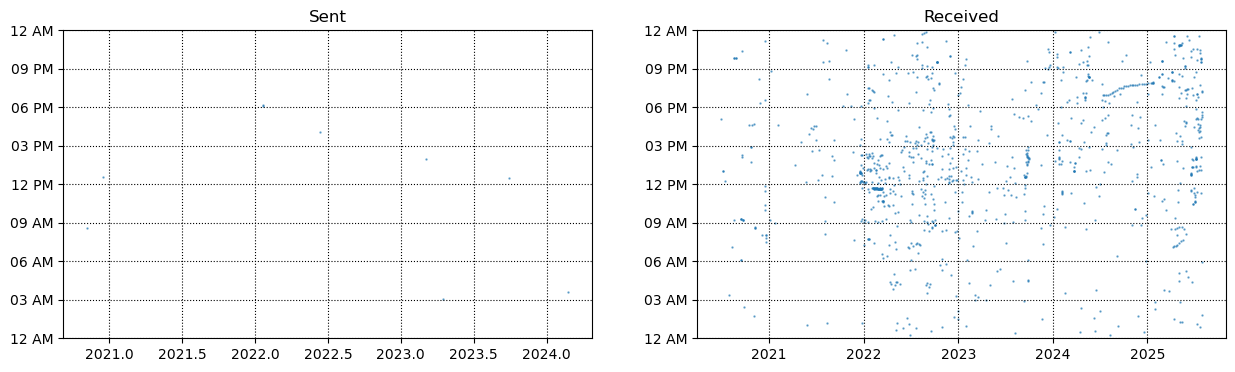

In [63]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
plot_todo_vs_year(sent, ax[0], title='Sent')
plot_todo_vs_year(received, ax[1], title='Received')

In [64]:
print(sent.head())
print(sent.columns)

                                                                     subject  \
date                                                                           
2022-01-20 18:07:15+01:00  Android registration/login issue 8.4.4 (25383)...   
2024-02-22 03:34:59+01:00  =?UTF-8?Q?Re=3A_Welcome_to_the_era_of_Galaxy_A...   
2020-11-05 08:35:46+01:00                                                NaN   
2020-12-13 12:32:40+01:00                                                NaN   
2023-04-16 03:05:51+01:00                                     Fwd: Chapter 2   

                                                from  \
date                                                   
2022-01-20 18:07:15+01:00  jemimahlabaran6@gmail.com   
2024-02-22 03:34:59+01:00  jemimahlabaran6@gmail.com   
2020-11-05 08:35:46+01:00  jemimahlabaran6@gmail.com   
2020-12-13 12:32:40+01:00  jemimahlabaran6@gmail.com   
2023-04-16 03:05:51+01:00  jemimahlabaran6@gmail.com   

                                              

In [65]:
print(received.head())
print(received.columns)

                                                                     subject  \
date                                                                           
2025-06-18 22:20:50+01:00      You Need To Hear: ffawty =?UTF-8?B?8J+Xow==?=   
2025-07-25 17:04:01+01:00  Drowning is a Leading Cause of Death for Children   
2025-07-18 15:38:23+01:00  Mobile Money Accounts Surpass Banks in Low-Inc...   
2025-07-08 13:59:07+01:00  =?UTF-8?Q?Jemimah=2C_check_out_how_Google=E2=8...   
2025-06-02 19:03:25+01:00   =?utf-8?B?TmV3IHdvcmRzLCBuZXcgcmV3YXJkcyDwn4+G?=   

                                                             from  \
date                                                                
2025-06-18 22:20:50+01:00        no-reply@marketing.audiomack.com   
2025-07-25 17:04:01+01:00          dailydata.en@news.statista.com   
2025-07-18 15:38:23+01:00          dailydata.en@news.statista.com   
2025-07-08 13:59:07+01:00  googlecommunityteam-noreply@google.com   
2025-06-02 19:03:25+01:00

In [66]:
def plot_number_perday_per_year(df, ax, label=None, dt=0.3,
**plot_kwargs):
    year = df[df['year'].notna()]['year'].values
    T = year.max() - year.min()
    bins = int(T / dt)
    weights = 1 / (np.ones_like(year) * dt * 365.25)
    ax.hist(year, bins=bins, weights=weights, label=label,
    **plot_kwargs);
    ax.grid(ls=':', color='k')

In [67]:
def plot_number_perdhour_per_year(df, ax, label=None, dt=1,
                                  smooth=False, weight_fun=None, **plot_kwargs):
    tod = df[df['timeofday'].notna()]['timeofday'].values
    year = df[df['year'].notna()]['year'].values

    Ty = year.max() - year.min()
    T = tod.max() - tod.min()
    bins = int(T / dt)

    # Compute weights
    if weight_fun is None:
        weights = 1 / (np.ones_like(tod) * Ty * 365.25 / dt)
    else:
        weights = weight_fun(df)

    # Histogram or smoothed line
    if smooth:
        hst, xedges = np.histogram(tod, bins=bins, weights=weights)
        x = np.delete(xedges, -1) + 0.5 * (xedges[1] - xedges[0])
        hst = ndimage.gaussian_filter(hst, sigma=0.75)

        f = interp1d(x, hst, kind='cubic')
        x = np.linspace(x.min(), x.max(), 10000)
        hst = f(x)

        ax.plot(x, hst, label=label, **plot_kwargs)
    else:
        ax.hist(tod, bins=bins, weights=weights, label=label, **plot_kwargs)

    # Formatting
    ax.grid(ls=':', color='k')
    orientation = plot_kwargs.get('orientation')

    if orientation is None or orientation == 'vertical':
        ax.set_xlim(0, 24)
        ax.xaxis.set_major_locator(MaxNLocator(8))
        ax.set_xticklabels([
            datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
            for ts in ax.get_xticks()
        ])
    elif orientation == 'horizontal':
        ax.set_ylim(0, 24)
        ax.yaxis.set_major_locator(MaxNLocator(8))
        ax.set_yticklabels([
            datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
            for ts in ax.get_yticks()
        ])

In [68]:
 class TriplePlot:
  def __init__(self):
    gs = gridspec.GridSpec(6, 6)
    self.ax1 = plt.subplot(gs[2:6, :4])
    self.ax2 = plt.subplot(gs[2:6, 4:6], sharey=self.ax1)
    plt.setp(self.ax2.get_yticklabels(), visible=False);
    self.ax3 = plt.subplot(gs[:2, :4])
    plt.setp(self.ax3.get_xticklabels(), visible=False);
  def plot(self, df, color='darkblue', alpha=0.8, markersize=0.5,
 yr_bin=0.1, hr_bin=0.5):
    plot_todo_vs_year(df, self.ax1, color=color, s=markersize)
    plot_number_perdhour_per_year(df, self.ax2, dt=hr_bin,
 color=color, alpha=alpha, orientation='horizontal')
    self.ax2.set_xlabel('Average emails per hour')
    plot_number_perday_per_year(df, self.ax3, dt=yr_bin,
 color=color, alpha=alpha)
    self.ax3.set_ylabel('Average emails per day')

In [69]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

C:\Users\USER\AppData\Local\Temp\ipykernel_12504\2181178046.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([
C:\Users\USER\AppData\Local\Temp\ipykernel_12504\2181178046.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


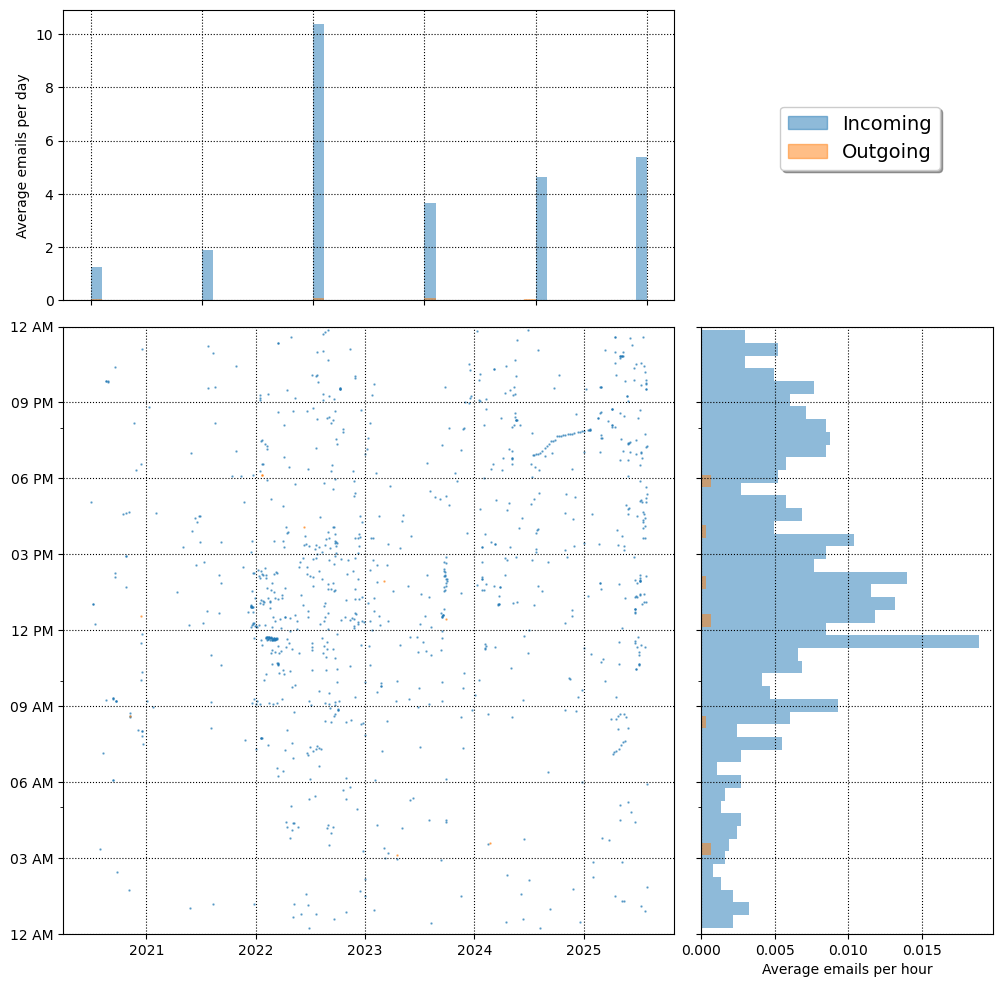

In [70]:
 plt.figure(figsize=(12,12));
 tpl = TriplePlot()
 tpl.plot(received, color='C0', alpha=0.5)
 tpl.plot(sent, color='C1', alpha=0.5)
 p1 = mpatches.Patch(color='C0', label='Incoming', alpha=0.5)
 p2 = mpatches.Patch(color='C1', label='Outgoing', alpha=0.5)
 plt.legend(handles=[p1, p2], bbox_to_anchor=[1.45, 0.7],
 fontsize=14, shadow=True);
 

In [71]:
 sdw = sent.groupby('dayofweek').size() / len(sent)
 rdw = received.groupby('dayofweek').size() / len(received)

C:\Users\USER\AppData\Local\Temp\ipykernel_12504\3902568330.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdw = sent.groupby('dayofweek').size() / len(sent)
C:\Users\USER\AppData\Local\Temp\ipykernel_12504\3902568330.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rdw = received.groupby('dayofweek').size() / len(received)


Busiest day of the week in terms of Email

<Axes: xlabel='dayofweek'>

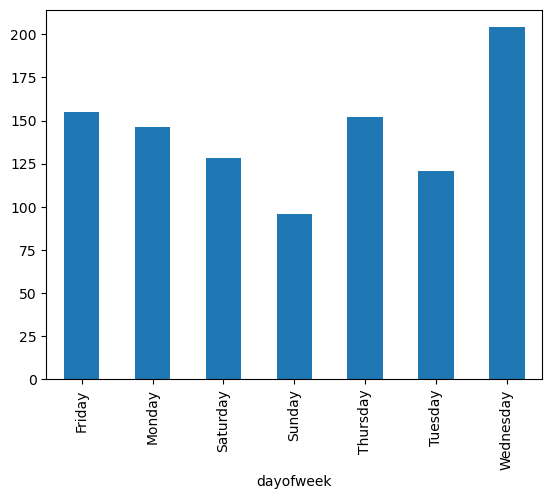

In [72]:
counts = gmail_data.dayofweek.value_counts(sort=False)
counts.plot(kind='bar')

Most actives days for Receiving and sending Emails

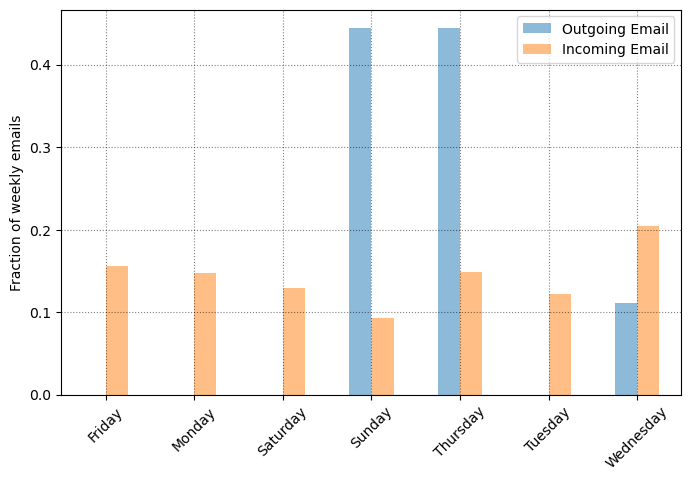

In [73]:
df_tmp = pd.DataFrame(data={'Outgoing Email': sdw, 'Incoming Email':rdw})
df_tmp.plot(kind='bar', rot=45, figsize=(8,5), alpha=0.5)
plt.xlabel('');
plt.ylabel('Fraction of weekly emails');
plt.grid(ls=':', color='k', alpha=0.5)

The most active time day for Email Communication

In [74]:
 import scipy.ndimage
 from scipy.interpolate import interp1d

In [75]:
def plot_number_perdhour_per_year(df, ax, label=None, dt=1,
                                  smooth=False, weight_fun=None, **plot_kwargs):
    tod = df[df['timeofday'].notna()]['timeofday'].values
    year = df[df['year'].notna()]['year'].values

    if len(tod) == 0 or len(year) == 0:
        return  # nothing to plot

    Ty = year.max() - year.min()
    T = tod.max() - tod.min()
    bins = int(T / dt)

    if bins <= 0:  # <-- new guard
        return  # not enough spread in data for histogram

    weights = weight_fun(tod) if weight_fun else None

    # Histogram or smoothed line
    if smooth:
        hst, xedges = np.histogram(tod, bins=bins, weights=weights)
        x = np.delete(xedges, -1) + 0.5 * (xedges[1] - xedges[0])
        hst = ndimage.gaussian_filter(hst, sigma=0.75)
        ax.plot(x, hst / hst.sum(), label=label, **plot_kwargs)
    else:
        ax.hist(tod, bins=bins, weights=weights, label=label, **plot_kwargs)


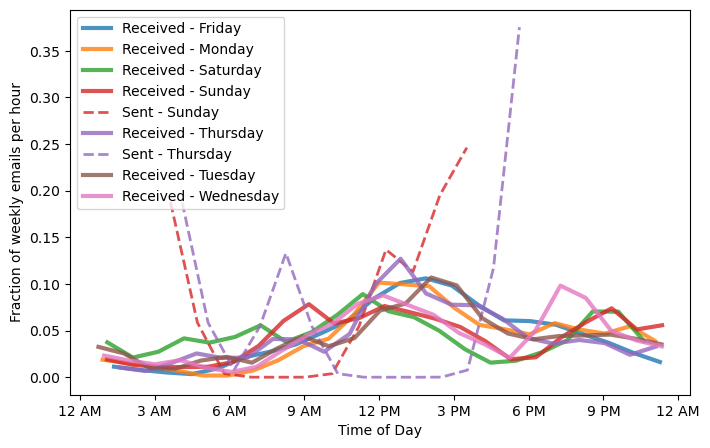

In [76]:
plt.figure(figsize=(8,5))
ax = plt.subplot(111)

for ct, dow in enumerate(gmail_data.dayofweek.cat.categories):
    # Received emails
    df_r = received[received['dayofweek'] == dow]
    if df_r.empty:
        continue
    weights = np.ones(len(df_r)) / len(received)
    wfun = lambda x: weights
    plot_number_perdhour_per_year(
        df_r, ax, dt=1, smooth=True,
        color=f'C{ct}', alpha=0.8, lw=3,
        label=f"Received - {dow}", weight_fun=wfun
    )

    # Sent emails
    gmail_data_day = sent[sent['dayofweek'] == dow]
    if gmail_data_day.empty:
        continue
    weights = np.ones(len(gmail_data_day)) / len(sent)
    wfun = lambda x: weights
    plot_number_perdhour_per_year(
        gmail_data_day, ax, dt=1, smooth=True,
        color=f'C{ct}', alpha=0.8, lw=2,
        label=f"Sent - {dow}", ls='--', weight_fun=wfun
    )

# Y-axis label
ax.set_ylabel('Fraction of weekly emails per hour')

# ✅ X-axis ticks (12AM → 12AM)
ax.set_xticks(range(0, 25, 3))
ax.set_xticklabels([
    "12 AM", "3 AM", "6 AM", "9 AM",
    "12 PM", "3 PM", "6 PM", "9 PM",
    "12 AM"
])
ax.set_xlabel("Time of Day")

# Legend + show
plt.legend(loc='upper left')
plt.show()


In [77]:
!pip install wordcloud


In [78]:
 from wordcloud import WordCloud
 df_no_arxiv = gmail_data[gmail_data['from'] != 'no-reply@arXiv.org']
 text = ' '.join(map(str, sent['subject'].values))

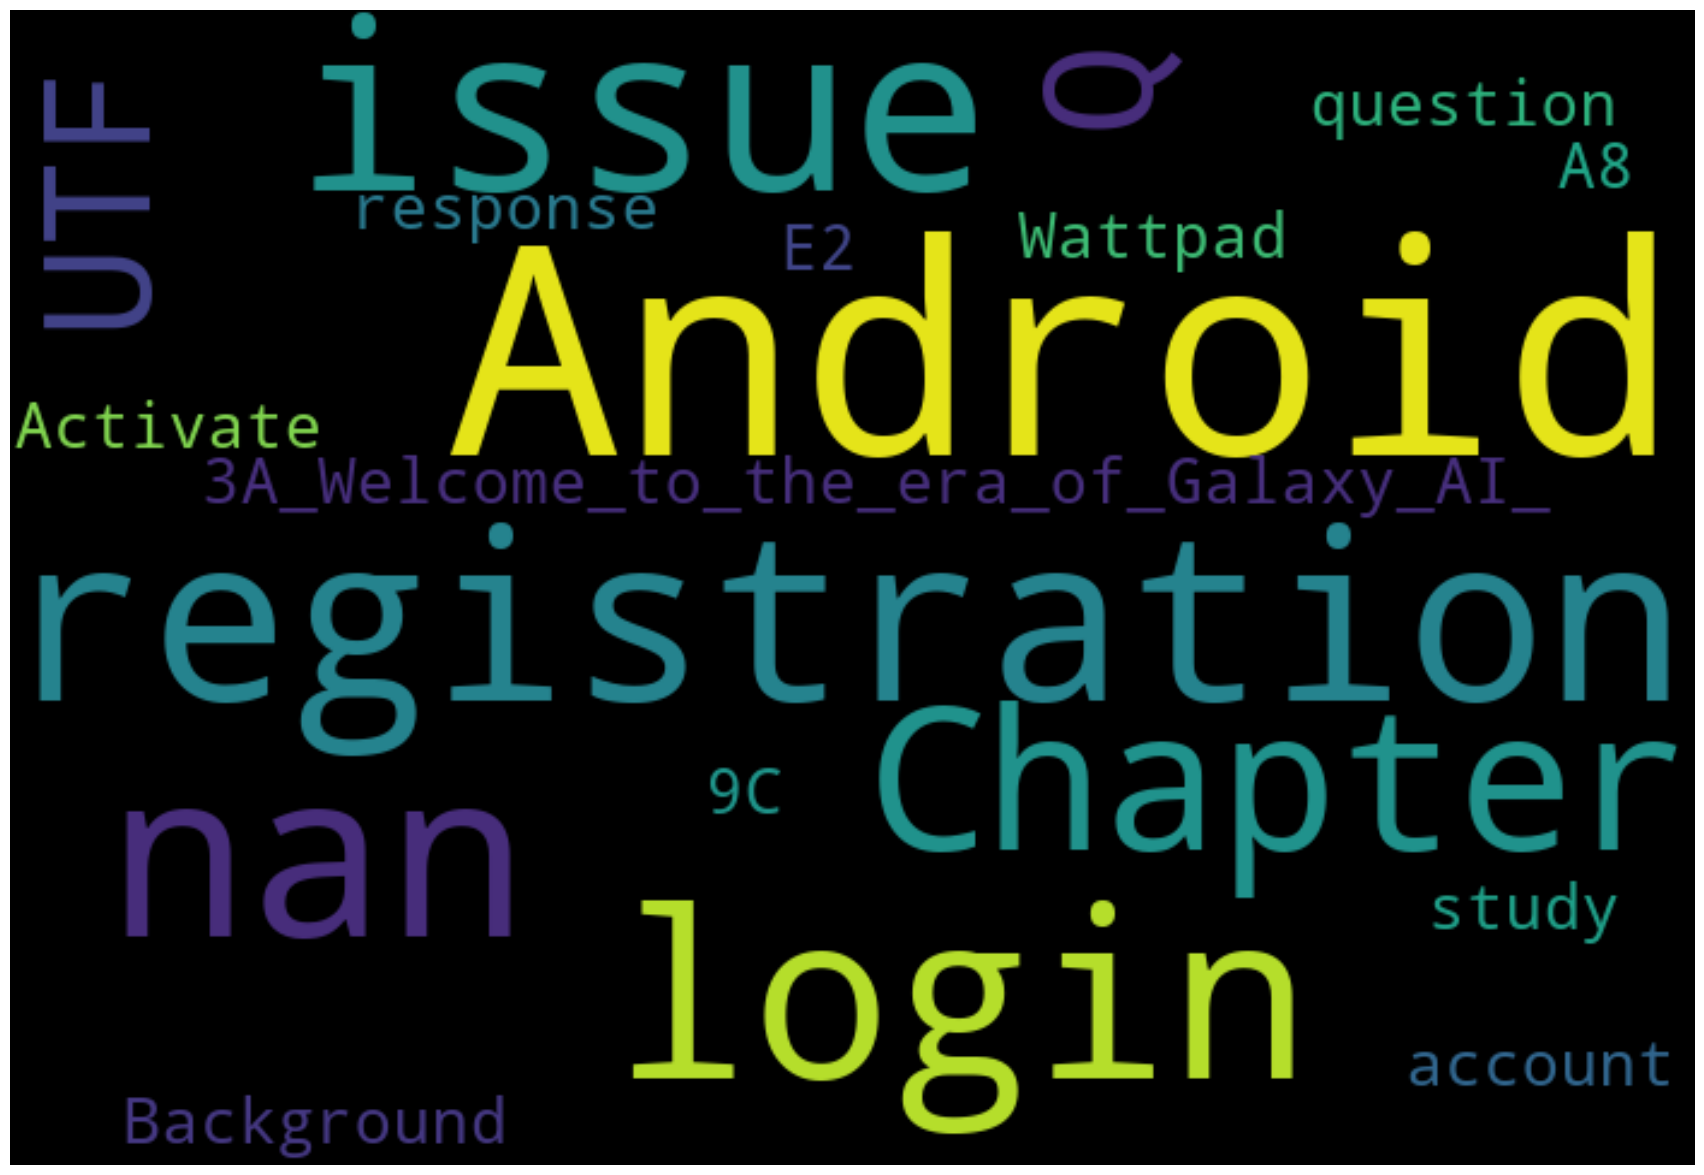

In [79]:
 stopwords = ['Re', 'Fwd', '3A_']
 wrd = WordCloud(width=700, height=480, margin=0, collocations=False)
 for sw in stopwords:
    wrd.stopwords.add(sw)
 wordcloud = wrd.generate(text)
 plt.figure(figsize=(25,15))
 plt.imshow(wordcloud, interpolation='bilinear')
 plt.axis("off")
 plt.margins(x=0, y=0)